# RQ1: Relação entre Enquadramento Temático e Postura da Audiência

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [28]:
BASE_DIR = Path.cwd().parent 

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

df_videos = pd.read_csv(BASE_DIR/"data/df_macrotopics.csv")
df_comentarios = pd.read_csv(BASE_DIR/"data/resultados_finais.csv")

# Filtra pelos macrotopicos relevantes
ids_ruido = df_videos.loc[
    df_videos['macrotopico'] == 'Ruído / Não-substantivo',
    'videoId'
]

df_comentarios = df_comentarios.loc[
    ~df_comentarios['videoId'].isin(ids_ruido)
].copy()

df_videos = df_videos.loc[
    ~df_videos['videoId'].isin(ids_ruido)
].copy()

df_master = pd.merge(
    df_comentarios,
    df_videos,
    on='videoId',
    how='left'
)

cores_sentimento = {'Negativo': '#E74C3C', 'Neutro': '#95A5A6', 'Positivo': '#2ECC71'}
dict_sentimento = {'Negativo': -1, 'Neutro': 0, 'Positivo': 1}
df_master['sentimento_num'] = df_master['feeling'].map(dict_sentimento)

df_master['publishedAt'] = pd.to_datetime(df_master['publishedAt'])

## Proporção de Sentimentos por Macro-tópico

In [ ]:
def analise_1_1(df):
    """
    Analise da Proporção de Sentimentos por Macro-tópico
    com gráfico de barras
    """
    # Contagem de sentimentos por macrotopico
    contagem = pd.crosstab(df['macrotopico'], df['feeling'])
    
    proporcao = contagem.div(contagem.sum(axis=1), axis=0) * 100
    
    if 'Negativo' in proporcao.columns:
        proporcao = proporcao.sort_values(by='Negativo', ascending=True)
    
    ax = proporcao[['Negativo', 'Neutro', 'Positivo']].plot(
        kind='barh', stacked=True, figsize=(10, 6), 
        color=[cores_sentimento[x] for x in ['Negativo', 'Neutro', 'Positivo']]
    )
    
    #plt.title('Proporção de Sentimentos por Macro-tópico', fontsize=14)
    plt.xlabel('Porcentagem (%)')
    plt.ylabel('Macro-tópico')
    plt.legend(title='Sentimento', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()

## Grau de Polarização dos Temas

In [ ]:
def analise_1_2(df):
    """
    Grau de Polarização dos Temas com gráfico de barras divergentes
    """
    contagem = pd.crosstab(df['macrotopico'], df['feeling'])
    proporcao = contagem.div(contagem.sum(axis=1), axis=0) * 100
    
    # Pega apenas Positivos e Negativos e inverte o valor dos Negativos para o eixo ir para a esq
    df_polar = proporcao[['Negativo', 'Positivo']].copy()
    df_polar['Negativo'] = df_polar['Negativo'] * -1
    
    # Ordena pelo tamanho da divergência
    df_polar['Total_Polarizacao'] = df_polar['Positivo'] + abs(df_polar['Negativo'])
    df_polar = df_polar.sort_values('Total_Polarizacao', ascending=True).drop(columns=['Total_Polarizacao'])
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    y = np.arange(len(df_polar.index))
    ax.barh(y, df_polar['Negativo'], color=cores_sentimento['Negativo'], label='Negativo')
    ax.barh(y, df_polar['Positivo'], color=cores_sentimento['Positivo'], label='Positivo')
    
    # Linha central zero
    ax.axvline(0, color='black', linewidth=1.2)
    
    ax.set_yticks(y)
    ax.set_yticklabels(df_polar.index)
    #plt.title('Grau de Polarização dos Temas (Divergência)', fontsize=14)
    plt.xlabel('Porcentagem Negativa (%) <----------   ----------> Porcentagem Positiva (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Relação entre Tom e Volume de Interação

In [ ]:
def analise_1_3(df):
    """Relação entre Tom e Volume de Interação com Gráfico de Bolhas"""
    volume = df.groupby('macrotopico').size().reset_index(name='Volume')
    
    # Calc índice de sentimento
    contagem = pd.crosstab(df['macrotopico'], df['feeling'])
    proporcao = contagem.div(contagem.sum(axis=1), axis=0) * 100
    proporcao['Indice_Sentimento'] = proporcao.get('Positivo', 0) - proporcao.get('Negativo', 0)
    
    df_bolhas = pd.merge(volume, proporcao[['Indice_Sentimento']].reset_index(), on='macrotopico')
    
    plt.figure(figsize=(10, 6))
    
    scatter = plt.scatter(x=df_bolhas['Indice_Sentimento'], y=df_bolhas['macrotopico'], 
                      s=df_bolhas['Volume']/10, alpha=0.4, c='royalblue', edgecolors='black', linewidth=1)
    
    # Linha neutra
    plt.axvline(0, color='gray', linestyle='--')
    
    #plt.title('Análise 1.3: Relação entre Tom e Volume de Interação', fontsize=14)
    plt.xlabel('Índice de Sentimento (% Positivo - % Negativo)\n<-- Mais Negativo | Mais Positivo -->')
    plt.ylabel('Macro-tópico')
    
    # rótulos de volume nas bolhas
    for i, row in df_bolhas.iterrows():
        plt.text(row['Indice_Sentimento'], i, f"{row['Volume']} com.", 
                 ha='center', va='center', fontsize=8, color='black')

    plt.tight_layout()
    plt.show()

## Consistência do Sentimento intra-Tópico

In [ ]:
def analise_1_4(df):
    """Consistência do Sentimento intra-Tópico com Gráfico de Boxplot por Macro-tópico"""
    contagem_video = pd.crosstab([df['videoId'], df['macrotopico']], df['feeling'])
    proporcao_video = contagem_video.div(contagem_video.sum(axis=1), axis=0) * 100
    proporcao_video = proporcao_video.reset_index()
    
    plt.figure(figsize=(10, 6))
    
    sns.boxplot(x='macrotopico', y='Negativo', data=proporcao_video, palette='pastel')
    # Adiciona pontos em cima do boxplot para ver a densidade real dos vídeos
    sns.stripplot(x='macrotopico', y='Negativo', data=proporcao_video, color='.3', alpha=0.5, size=5)
    
    #plt.title('Análise 1.4: Consistência do Sentimento intra-Tópico (Tom Negativo)', fontsize=14)
    plt.xlabel('Macro-tópico')
    plt.ylabel('Proporção de Comentários Negativos no Vídeo (%)')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

## Gerar gráficos

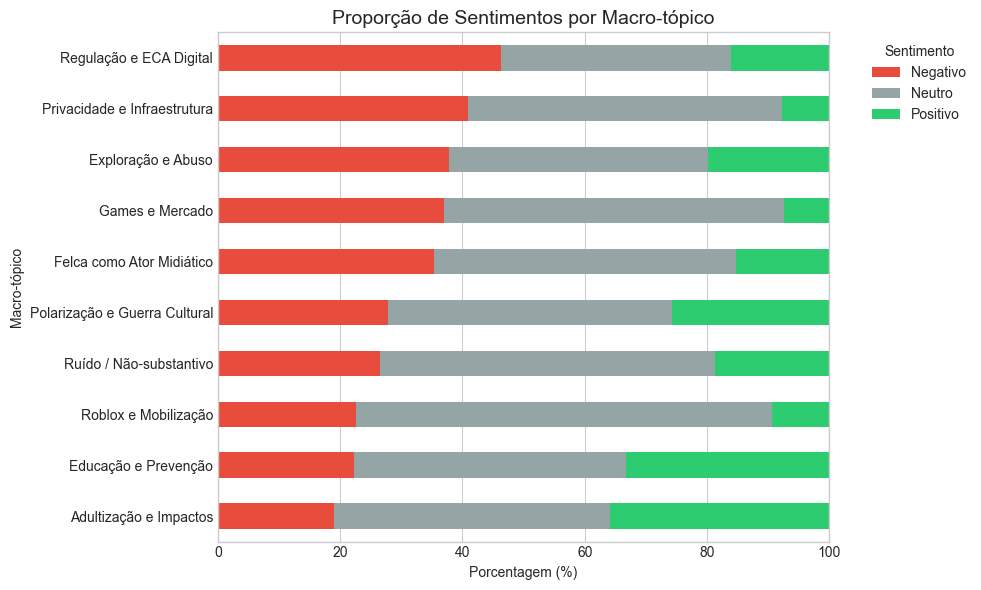

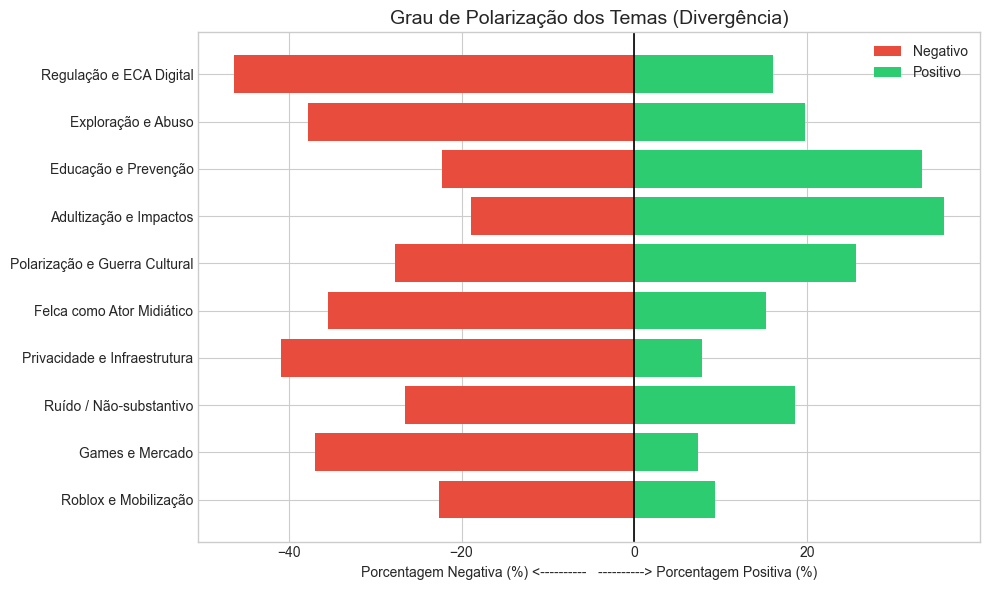

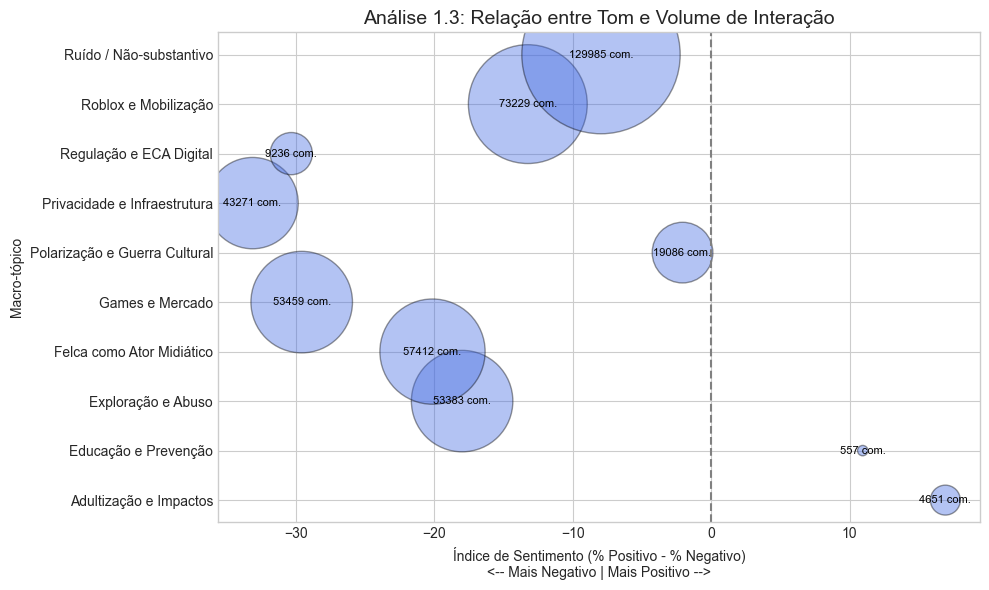

C:\Users\Nathan\AppData\Local\Temp\ipykernel_7920\717822861.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='macrotopico', y='Negativo', data=proporcao_video, palette='pastel')


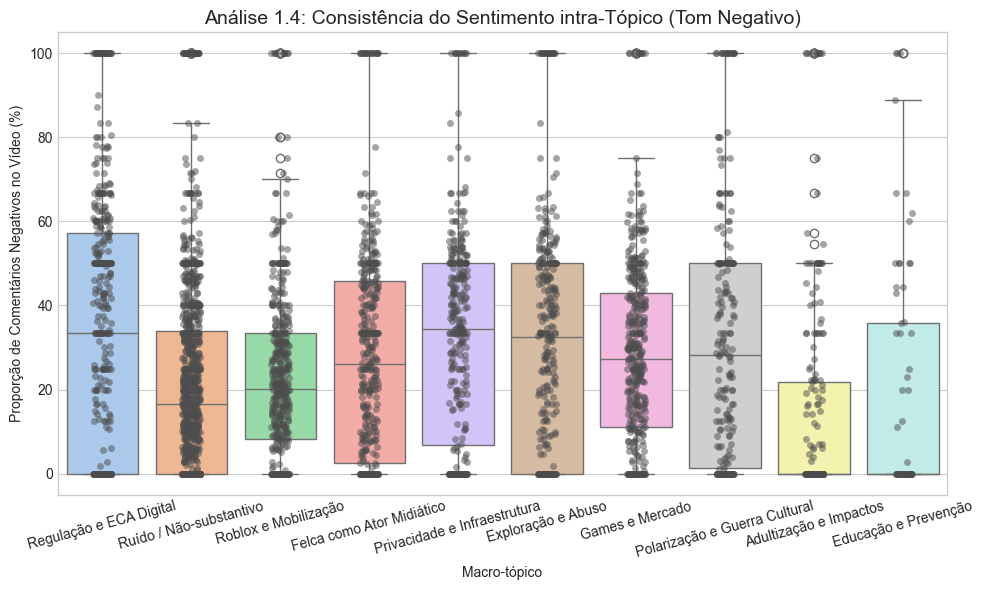

In [7]:
analise_1_1(df_master)
analise_1_2(df_master)
analise_1_3(df_master)
analise_1_4(df_master)

## Novas análises
## Mapa de calor (Criador x Macro-tópico)

In [ ]:
def analise_1_5(df, top_n=15):
    top_canais = df['channelTitle'].value_counts().nlargest(top_n).index
    df_filtrado = df[df['channelTitle'].isin(top_canais)]
    
    plt.figure(figsize=(12, 10))
    pivot_df = pd.pivot_table(df_filtrado, values='sentimento_num', index='channelTitle', columns='macrotopico', aggfunc='mean')
    
    sns.heatmap(pivot_df, annot=True, cmap='RdYlGn', center=0, fmt=".2f", 
                linewidths=.5, cbar_kws={'label': 'Média de Sentimento (-1 a 1)'})
    
    #plt.title(f'Análise 1.5: Média de Sentimento (Top {top_n} Canais Mais Comentados)', fontsize=14)
    plt.xlabel('Macro-tópico', fontsize=12)
    plt.ylabel('Canal (Criador de Conteúdo)', fontsize=12)
    
    plt.xticks(rotation=30, ha='right')
    
    plt.tight_layout()
    plt.show()

## Evolução Temporal da Negatividade

In [ ]:
def analise_1_6(df):
    plt.figure(figsize=(12, 6))
    
    df['semana'] = df['publishedAt'].dt.to_period('W').dt.start_time
    
    # Calc da proporção de negativos por semana e tópico
    agrupado = df.groupby(['semana', 'macrotopico', 'feeling']).size().unstack(fill_value=0)
    agrupado['Total'] = agrupado.sum(axis=1)
    agrupado['% Negativo'] = (agrupado.get('Negativo', 0) / agrupado['Total']) * 100
    agrupado = agrupado.reset_index()
    
    sns.lineplot(data=agrupado, x='semana', y='% Negativo', hue='macrotopico', marker='o', linewidth=2)
    
    #plt.title('Análise 1.6: Evolução da Negatividade ao Longo do Tempo', fontsize=14)
    plt.xlabel('Data de Publicação do Vídeo')
    plt.ylabel('Proporção de Comentários Negativos (%)')
    plt.legend(title='Macro-tópico', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Zoom no Topico_Atribuido (Micro-Tópicos)

In [ ]:
def analise_1_7(df):
    # Escolha o macro-tópico
    alvo = df['macrotopico'].value_counts().index[0] 
    df_focado = df[df['macrotopico'] == alvo]
    
    contagem = pd.crosstab(df_focado['Topico_Atribuido'], df_focado['feeling'])
    proporcao = contagem.div(contagem.sum(axis=1), axis=0) * 100
    
    cores = {'Negativo': '#E74C3C', 'Neutro': '#95A5A6', 'Positivo': '#2ECC71'}
    cols = [c for c in ['Negativo', 'Neutro', 'Positivo'] if c in proporcao.columns]
    
    proporcao[cols].plot(kind='barh', stacked=True, figsize=(10, 5), color=[cores[c] for c in cols])
    
    #plt.title(f'Análise 1.7: Sentimentos nos Micro-tópicos de "{alvo}"', fontsize=14)
    plt.xlabel('Porcentagem (%)')
    plt.ylabel('Tópico Atribuído (Micro-tópico)')
    plt.legend(title='Sentimento', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()

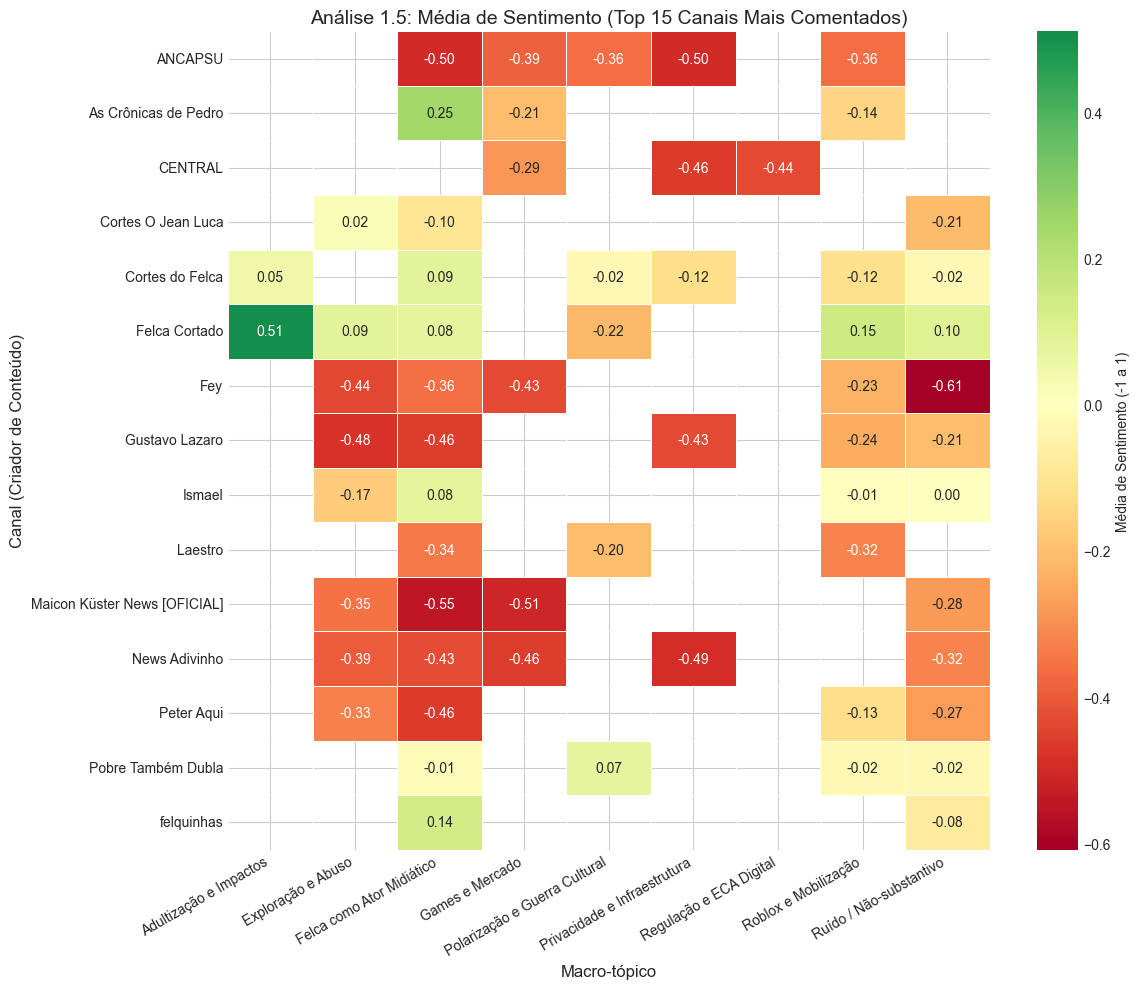

C:\Users\Nathan\AppData\Local\Temp\ipykernel_7920\193913372.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['semana'] = df['publishedAt'].dt.to_period('W').dt.start_time


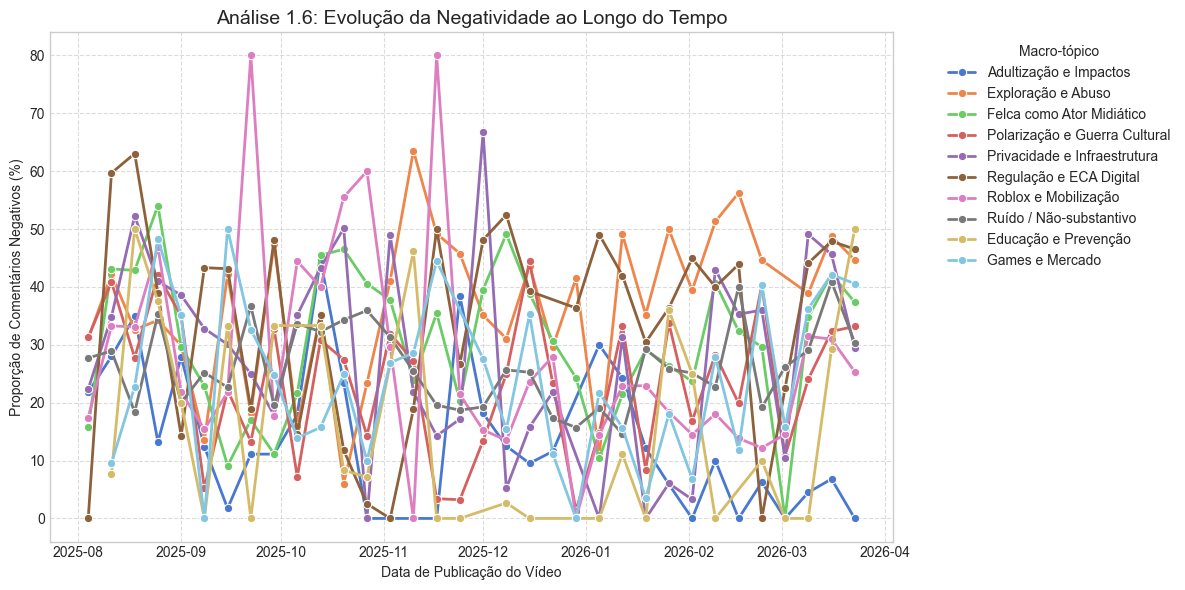

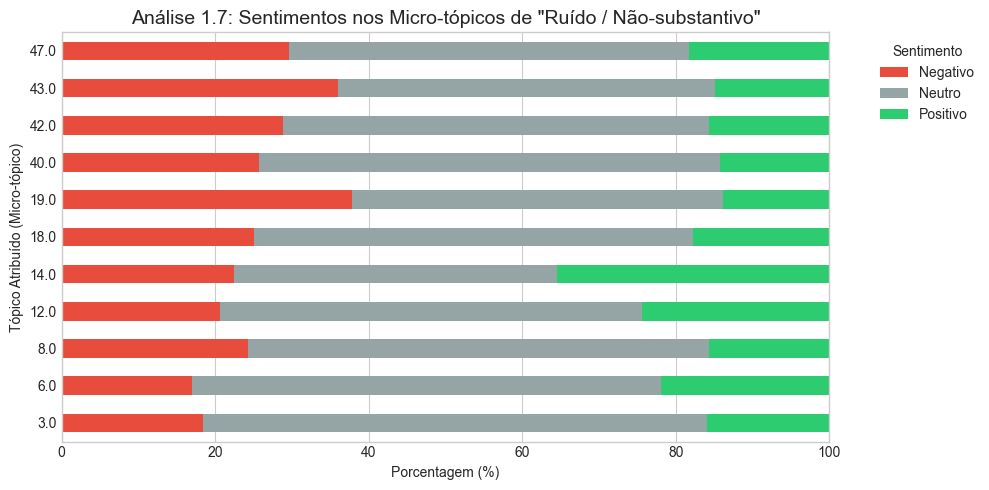

In [11]:
analise_1_5(df_master)
analise_1_6(df_master)
analise_1_7(df_master)